# 18 · End-to-End Machine Learning Project

**Difficulty:** Advanced | **Time:** ~4 hours

This is the **capstone notebook** — a complete ML project from raw data to deployment-ready model.

**Problem:** Predict whether a bank customer will subscribe to a term deposit (marketing campaign).

## Complete Workflow
1. Problem Definition
2. Data Collection & Loading
3. Exploratory Data Analysis
4. Feature Engineering
5. Data Preprocessing Pipeline
6. Model Training & Comparison
7. Hyperparameter Tuning
8. Model Interpretation
9. Final Evaluation
10. Model Saving & Deployment

## 1. Problem Definition

**Business Question:** Which customers are likely to subscribe to a term deposit?

**ML Framing:** Binary Classification (subscribe=1, not subscribe=0)

**Success Metric:** AUC-ROC (because data is imbalanced)

**Baseline:** Random prediction → AUC=0.5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier)
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report,
                              confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.inspection import permutation_importance
import joblib, warnings
warnings.filterwarnings('ignore')
print('All libraries loaded ✓')

All libraries loaded ✓


## 2. Data Generation (Simulating Bank Marketing Dataset)

In [2]:
np.random.seed(42)
N = 5000

# Customer features
age = np.random.randint(18, 75, N)
job = np.random.choice(['admin','technician','services','management',
                          'retired','blue-collar','student'], N,
                         p=[0.25,0.18,0.12,0.15,0.08,0.15,0.07])
marital = np.random.choice(['married','single','divorced'], N, p=[0.6,0.28,0.12])
education = np.random.choice(['primary','secondary','tertiary'], N, p=[0.15,0.5,0.35])
default = np.random.choice(['yes','no'], N, p=[0.02,0.98])
balance = np.random.normal(1500, 3000, N).clip(-500, 30000).astype(int)
housing = np.random.choice(['yes','no'], N, p=[0.55,0.45])
loan = np.random.choice(['yes','no'], N, p=[0.16,0.84])
call_type = np.random.choice(['cellular','telephone','unknown'], N, p=[0.64,0.21,0.15])
call_duration = np.random.exponential(250, N).clip(1, 3000).astype(int)
n_contacts = np.random.poisson(2, N).clip(1, 20)
previous = np.random.poisson(0.5, N).clip(0, 5).astype(int)

# Target: subscription probability
logit = (
    -2.5
    + (age > 60).astype(int) * 0.5
    + (job == 'student').astype(int) * 0.8
    + (job == 'retired').astype(int) * 0.6
    + (education == 'tertiary').astype(int) * 0.5
    + balance / 30000 * 2
    + np.log1p(call_duration) * 0.4
    + previous * 0.3
    - n_contacts * 0.1
    + (default == 'no').astype(int) * 0.4
)
prob = 1 / (1 + np.exp(-logit))
subscribed = (np.random.random(N) < prob).astype(int)

df = pd.DataFrame({
    'age':age, 'job':job, 'marital':marital, 'education':education,
    'default':default, 'balance':balance, 'housing':housing, 'loan':loan,
    'contact':call_type, 'duration':call_duration,
    'campaign':n_contacts, 'previous':previous, 'y':subscribed
})

# Add some missing values
for col, pct in [('job', 0.02), ('education', 0.03), ('contact', 0.05)]:
    mask = np.random.random(N) < pct
    df.loc[mask, col] = np.nan

print(f'Dataset: {df.shape}')
print(f'Subscription rate: {df.y.mean():.1%} (imbalanced!)')
print(df.head())

Dataset: (5000, 13)
Subscription rate: 57.3% (imbalanced!)
   age          job   marital  education default  balance housing loan  \
0   56        admin  divorced   tertiary      no     1576      no   no   
1   69        admin  divorced        NaN      no     -500      no   no   
2   46   technician   married  secondary      no     3966      no   no   
3   32  blue-collar   married    primary      no     6485     yes   no   
4   60        admin   married  secondary      no     -416     yes   no   

    contact  duration  campaign  previous  y  
0  cellular       362         1         0  1  
1  cellular       451         1         0  1  
2       NaN       181         1         0  0  
3  cellular       187         1         1  1  
4  cellular        88         3         1  1  


## 3. EDA

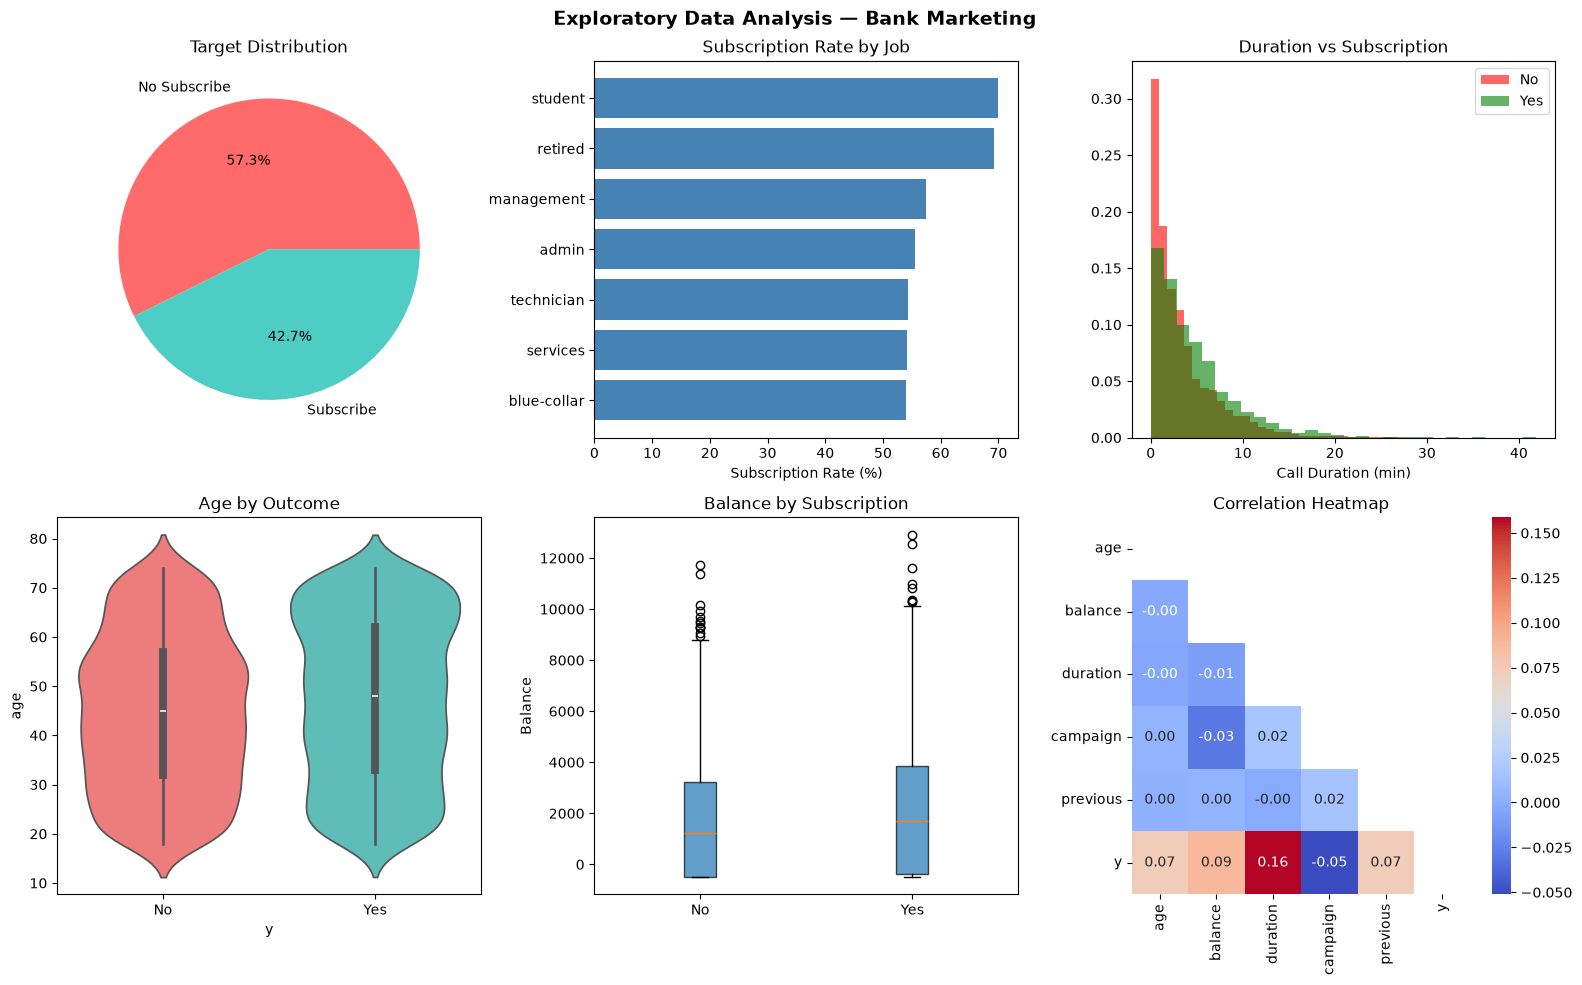

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Target distribution
vc = df.y.value_counts()
axes[0,0].pie(vc.values, labels=['No Subscribe','Subscribe'],
               autopct='%1.1f%%', colors=['#FF6B6B','#4ECDC4'])
axes[0,0].set_title('Target Distribution')

# Subscription rate by job
job_rate = df.groupby('job')['y'].mean().sort_values()
axes[0,1].barh(job_rate.index, job_rate.values*100, color='steelblue')
axes[0,1].set_title('Subscription Rate by Job')
axes[0,1].set_xlabel('Subscription Rate (%)')

# Duration vs subscription
subs = df[df.y==1]['duration']
non  = df[df.y==0]['duration']
axes[0,2].hist(non/60,  bins=30, alpha=0.6, color='red',   label='No',  density=True)
axes[0,2].hist(subs/60, bins=30, alpha=0.6, color='green', label='Yes', density=True)
axes[0,2].set_xlabel('Call Duration (min)'); axes[0,2].legend()
axes[0,2].set_title('Duration vs Subscription')

# Age distribution by outcome
sns.violinplot(data=df, x='y', y='age', ax=axes[1,0], palette=['#FF6B6B','#4ECDC4'])
axes[1,0].set_xticklabels(['No','Yes']); axes[1,0].set_title('Age by Outcome')

# Balance by subscription
axes[1,1].boxplot([df[df.y==0]['balance'], df[df.y==1]['balance']],
                   tick_labels=['No','Yes'], patch_artist=True,
                   boxprops={'alpha':0.7})
axes[1,1].set_title('Balance by Subscription'); axes[1,1].set_ylabel('Balance')

# Correlation heatmap (numeric)
numeric = df[['age','balance','duration','campaign','previous','y']]
corr = numeric.corr()
mask = np.triu(np.ones_like(corr))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm', ax=axes[1,2])
axes[1,2].set_title('Correlation Heatmap')

plt.suptitle('Exploratory Data Analysis — Bank Marketing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/eda_bank.png', dpi=100)
plt.show()

## 4. Feature Engineering

In [4]:
def engineer_features(df):
    df = df.copy()
    # Log transform skewed features
    df['log_duration'] = np.log1p(df['duration'])
    df['log_balance']  = np.log1p(df['balance'].clip(0))
    # Age groups
    df['age_group'] = pd.cut(df['age'], bins=[0,25,35,50,65,100],
                              labels=['<25','25-35','35-50','50-65','65+'])
    # Previous contact flag
    df['had_previous'] = (df['previous'] > 0).astype(int)
    # Campaign intensity
    df['high_campaign'] = (df['campaign'] > 5).astype(int)
    return df

df_fe = engineer_features(df)
print('New features added:')
new_feats = ['log_duration','log_balance','age_group','had_previous','high_campaign']
print(df_fe[new_feats].head())

New features added:
   log_duration  log_balance age_group  had_previous  high_campaign
0      5.894403     7.363280     50-65             0              0
1      6.113682     0.000000       65+             0              0
2      5.204007     8.285765     35-50             0              0
3      5.236442     8.777401     25-35             1              0
4      4.488636     0.000000     50-65             1              0


## 5. Preprocessing Pipeline

In [5]:
X = df_fe.drop('y', axis=1)
y = df_fe['y']

# Split first — never fit preprocessors on test data!
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                            random_state=42, stratify=y)

# Define columns
numeric_feats     = ['age','balance','duration','campaign','previous',
                      'log_duration','log_balance','had_previous','high_campaign']
categorical_feats = ['job','marital','education','default','housing','loan','contact','age_group']

# Sub-pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, numeric_feats),
    ('cat', cat_pipe, categorical_feats),
])

# Fit preprocessor on train only
X_tr_prep = preprocessor.fit_transform(X_tr)
X_te_prep = preprocessor.transform(X_te)

print(f'Original features: {X_tr.shape[1]}')
print(f'After preprocessing: {X_tr_prep.shape[1]}')

Original features: 17
After preprocessing: 36


## 6. Model Training & Comparison

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest'        : RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_results = {}
print(f'{'Model':<25} {'CV AUC':>10} {'Std':>8}')
print('-' * 45)
for name, model in models.items():
    cv_aucs = cross_val_score(model, X_tr_prep, y_tr, cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = cv_aucs
    print(f'{name:<25} {cv_aucs.mean():>10.4f} {cv_aucs.std():>8.4f}')

Model                         CV AUC      Std
---------------------------------------------


Logistic Regression           0.6699   0.0168


Random Forest                 0.6431   0.0139


Gradient Boosting             0.6610   0.0214


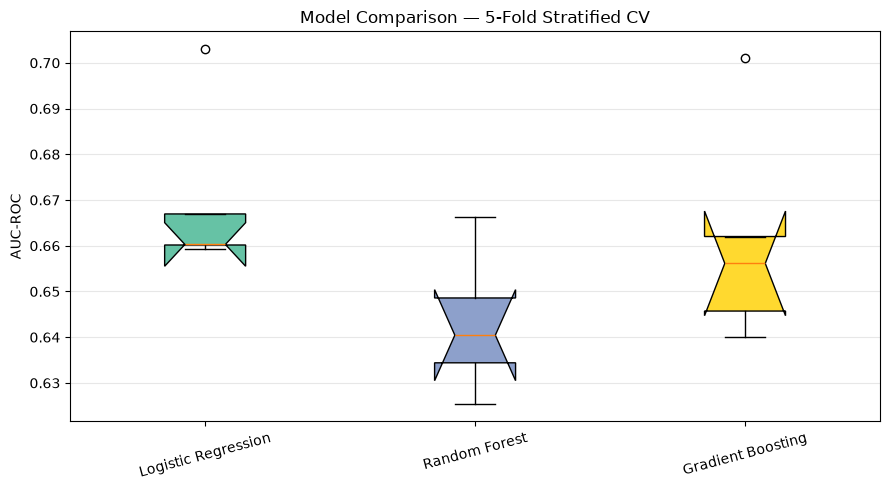

In [7]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot([cv_results[m] for m in models], tick_labels=list(models.keys()),
                 patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], plt.cm.Set2([0, 0.33, 0.66])):
    patch.set_facecolor(color)
ax.set_ylabel('AUC-ROC'); ax.set_title('Model Comparison — 5-Fold Stratified CV')
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('/tmp/model_compare.png', dpi=100)
plt.show()

## 7. Train Best Model & Evaluate

In [8]:
# Train final model
best_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                         max_depth=5, random_state=42)
best_model.fit(X_tr_prep, y_tr)
y_pred  = best_model.predict(X_te_prep)
y_prob  = best_model.predict_proba(X_te_prep)[:,1]

print('=== FINAL MODEL EVALUATION ===')
print(classification_report(y_te, y_pred, target_names=['No Subscribe','Subscribe']))
print(f'AUC-ROC: {roc_auc_score(y_te, y_prob):.4f}')

=== FINAL MODEL EVALUATION ===
              precision    recall  f1-score   support

No Subscribe       0.53      0.44      0.49       427
   Subscribe       0.63      0.71      0.67       573

    accuracy                           0.60      1000
   macro avg       0.58      0.58      0.58      1000
weighted avg       0.59      0.60      0.59      1000

AUC-ROC: 0.6163


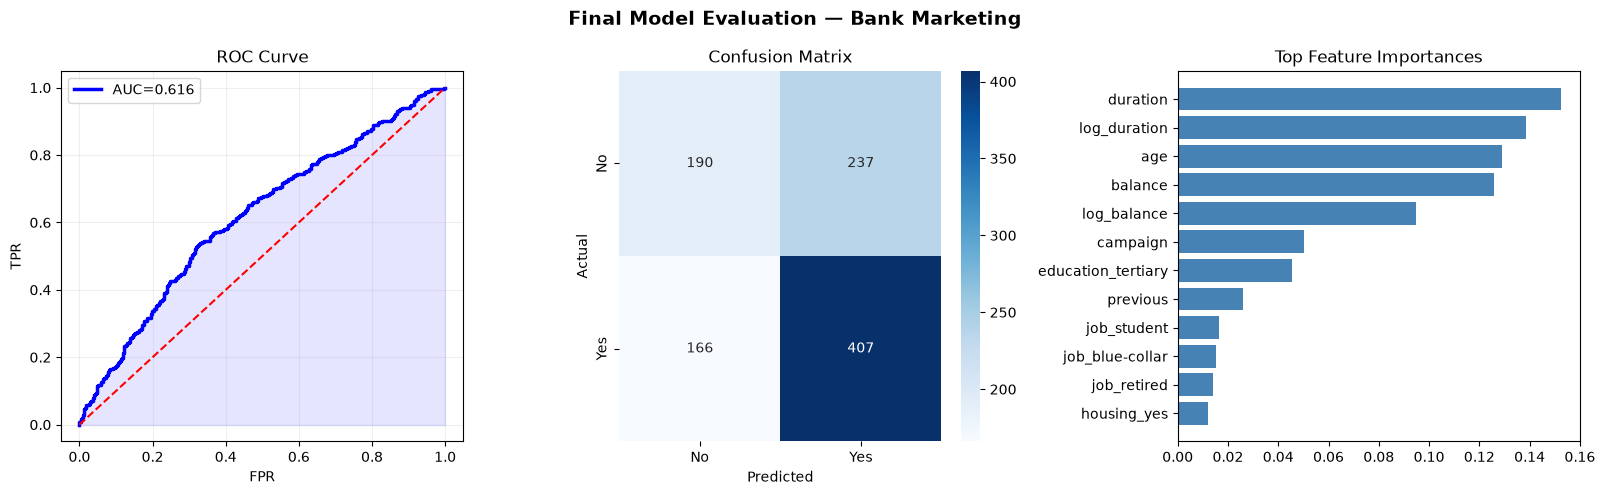

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
fpr, tpr, _ = roc_curve(y_te, y_prob)
auc = roc_auc_score(y_te, y_prob)
axes[0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'AUC={auc:.3f}')
axes[0].plot([0,1],[0,1],'r--'); axes[0].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[0].set_title('ROC Curve'); axes[0].legend(); axes[0].grid(alpha=0.2)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
             xticklabels=['No','Yes'], yticklabels=['No','Yes'])
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# Feature Importance (top 15)
try:
    numeric_names = numeric_feats
    cat_names = list(preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(categorical_feats))
    all_names  = numeric_names + cat_names
    imp_df = pd.DataFrame({'Feature': all_names, 'Importance': best_model.feature_importances_})
except:
    imp_df = pd.DataFrame({'Feature': [f'F{i}' for i in range(len(best_model.feature_importances_))],
                            'Importance': best_model.feature_importances_})

imp_top = imp_df.sort_values('Importance', ascending=True).tail(12)
axes[2].barh(imp_top['Feature'], imp_top['Importance'], color='steelblue')
axes[2].set_title('Top Feature Importances')

plt.suptitle('Final Model Evaluation — Bank Marketing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/tmp/final_eval.png', dpi=100)
plt.show()

## 8. Save & Load Model (Production Deployment)

In [10]:
import joblib, os

# Save everything needed for production
model_artifacts = {
    'preprocessor': preprocessor,
    'model'        : best_model,
    'feature_names': list(X.columns),
    'target_names' : ['No Subscribe', 'Subscribe'],
    'threshold'    : 0.4  # tuned threshold
}

joblib.dump(model_artifacts, '/tmp/bank_model.pkl')
print(f'Model saved: {os.path.getsize("/tmp/bank_model.pkl") / 1024:.1f} KB')

# Load and use
loaded = joblib.load('/tmp/bank_model.pkl')

# Simulate production prediction
new_customer = pd.DataFrame([{
    'age':35, 'job':'technician', 'marital':'married', 'education':'tertiary',
    'default':'no', 'balance':2500, 'housing':'yes', 'loan':'no',
    'contact':'cellular', 'duration':300, 'campaign':1, 'previous':0,
    'log_duration': np.log1p(300), 'log_balance': np.log1p(2500),
    'age_group':'35-50', 'had_previous':0, 'high_campaign':0
}])

X_new_prep = loaded['preprocessor'].transform(new_customer)
prob_subscribe = loaded['model'].predict_proba(X_new_prep)[0,1]
decision = 'SUBSCRIBE' if prob_subscribe >= loaded['threshold'] else 'NO SUBSCRIBE'

print(f'\nPrediction for new customer:')
print(f'  Probability of subscribing: {prob_subscribe:.1%}')
print(f'  Decision (threshold={loaded["threshold"]}): {decision}')

Model saved: 846.6 KB

Prediction for new customer:
  Probability of subscribing: 84.7%
  Decision (threshold=0.4): SUBSCRIBE


## Summary — Complete ML Workflow

```
1. Problem Definition      ← Business question + ML framing
2. Data Collection         ← Load, inspect, check quality
3. EDA                     ← Understand distributions, relationships
4. Feature Engineering     ← Transform, create new features
5. Preprocessing Pipeline  ← Scale, encode (fit on train ONLY)
6. Model Comparison        ← Cross-validate multiple models
7. Hyperparameter Tuning   ← GridSearch/RandomSearch
8. Final Evaluation        ← Once on holdout test set
9. Model Interpretation    ← Feature importance, SHAP
10. Save & Deploy          ← joblib + REST API (FastAPI/Flask)
```

**Congratulations! You now know the complete ML workflow.**

**Next notebook →** `19_Advanced_Topics_Review.ipynb`